# Esperimenti sul dataset con pazienti/malattie

## Esperimenti su grafi differenti, uno l'espansione dell'altro

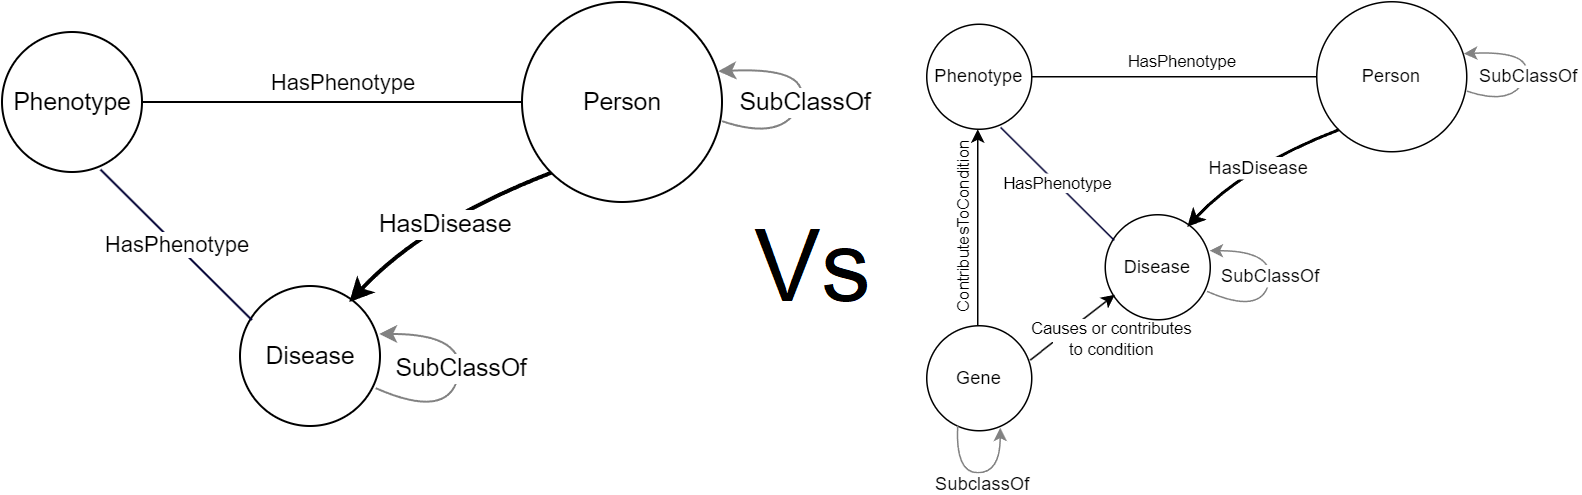

## Suddivisione train, val, test: 151'076, 15'143 e 779
### Sono incluse tutte le connessioni che coinvolgono le malattie associate ai pazienti e anche le loro malattie "parent"

## Test set creato esclusivamente sugli archi "Has disease"

In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import math
from utilities import print_metricsKGE, print_times, stampa_tempi, carica_file, printBARS, printBARST
from sklearn.decomposition import PCA

stampa = False
data_dir = "C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/"

grid = ["l0.05|dim2", "l0.05|dim4", "l0.05|dim8", "l0.05|dim10", "l0.05|dim26", "l0.05|dim128"]

## Grid search esaustivo sugli iperparametri

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from utilities import caricaLogKGE

seeds = ["", "_2", "_3"]

data_dirs = [data_dir+"AttHN/", data_dir+"AttEN/"]
data_dirs2 = [data_dir+"AttHG/", data_dir+"AttEG/"]
combinations = [["2", "4", "8", "10", "26", "128"], ["2", "4", "8", "10", "26", "128"]]

MRRS, MRRS2 = [[], []], [[], []]
MRS, MRS2 = [[], []], [[], []]
H1S, H1S2 =  [[], []], [[], []]
allT, allT2 =  [[], []], [[], []]
allTm, allTm2 =  [[], []], [[], []]

for i in range(len(data_dirs)):
    root = data_dirs[i]
    root2 = data_dirs2[i]
    for s in seeds:
        mrrs = []
        mrs = []
        h1s = []
        times = []
        times2 = []
        for j in combinations[i]:
            p = root + j + str(s)

            mr, mrr, h1, _, _, time = caricaLogKGE(p)
            mrrs.append(mrr[0])
            mrs.append(mr[0])
            h1s.append(h1[0])
            times.append(np.sum(time))
            times2.append(np.mean(time))
        MRRS[i].append(mrrs)
        MRS[i].append(mrs)
        H1S[i].append(h1s)
        allT[i].append(times)
        allTm[i].append(times2)
        
        mrrs = []
        mrs = []
        h1s = []
        times = []
        times2 = []        
        for j in combinations[i]:
            p = root2 + j + str(s)

            mr, mrr, h1, _, _, time = caricaLogKGE(p)
            mrrs.append(mrr[0])
            mrs.append(mr[0])
            h1s.append(h1[0])
            times.append(np.sum(time))
            times2.append(np.mean(time))
        MRRS2[i].append(mrrs)
        MRS2[i].append(mrs)
        H1S2[i].append(h1s)
        allT2[i].append(times)
        allTm2[i].append(times2)

# Confronto con i metodi HGCN e GCN

In [3]:
import pandas as pd
import numpy as np
from utilities import print_times

mrrs, mrrs2 = [], []
mrs, mrs2 = [], []
h1s, h1s2 = [], []
rnk, rnk2 = [], []

for model in ["hgcn", "gcn"]:
    for n in [55, 57, 59]:

        f = pd.read_csv(data_dir+"../rsN" + str(n) + model + ".csv")
        f2 = pd.read_csv(data_dir+"../rsG" + str(n) + model + ".csv")

        pazienti = np.unique(f["patient"])
        pazienti2 = np.unique(f2["patient"])

        test = pd.read_csv(data_dir+"../disease_lp.edgesNoGF"+str(n)+".csv")
        test2 = pd.read_csv(data_dir+"../disease_lp.edgesGene"+str(n)+".csv")
        test = test.rename(columns={"0": "subject", "1": "object"})
        test2 = test2.rename(columns={"0": "subject", "1": "object"})

        pool = test[:780]
        
        rank, irank = [], []
        for i in pazienti:
            # prendo la malattia vera associata al paziente
            j = pool[pool["subject"]==i]["object"].values.item()

            # vedo tutte le malattie ordinate per probabilità decrescente
            p = f[f["patient"]==i]
            p = p.sort_values(by="prob", ascending=False)
            p = p.reset_index()

            # lista ordinata delle malattie in ordine di probabilità decrescente
            res = list(p["disease"].values)
            if j in res:
                idx = res.index(j)+1
                irank.append(1/idx)
                rank.append(idx)
        rnk.append(rank)
        mrs.append(np.mean(rank))
        mrrs.append(np.mean(irank))
        h1s.append(np.mean([1 if x == 1 else 0 for x in rank]))
        
        pool = test2[:780]
        
        rank, irank = [], []
        for i in pazienti2:
            # prendo la malattia vera associata al paziente
            j = pool[pool["subject"]==i]["object"].values.item()

            # vedo tutte le malattie ordinate per probabilità decrescente
            p = f2[f2["patient"]==i]
            p = p.sort_values(by="prob", ascending=False)
            p = p.reset_index()

            # lista ordinata delle malattie in ordine di probabilità decrescente
            res = list(p["disease"].values)
            if j in res:
                idx = res.index(j)+1
                irank.append(1/idx)
                rank.append(idx)
        rnk2.append(rank)
        mrs2.append(np.mean(rank))
        mrrs2.append(np.mean(irank))
        h1s2.append(np.mean([1 if x == 1 else 0 for x in rank]))

In [4]:
times = []
hgcn = data_dir+"2026_1_20_gridHGCNnoGF55/11"
hgcn2 = data_dir+"2026_1_20_gridHGCNnoGF57/11"
hgcn3 = data_dir+"2026_1_20_gridHGCNnoGF59/11"
gcn = data_dir+"2026_1_20_gridGCNnoGF55/11"
gcn2 = data_dir+"2026_1_20_gridGCNnoGF57/11"
gcn3 = data_dir+"2026_1_20_gridGCNnoGF59/11"

for i in [hgcn, hgcn2, hgcn3, gcn, gcn2, gcn3]:
    times.append([np.sum(np.array(print_times(i+"/log.txt", False)[0])*15), np.mean(print_times(hgcn+"/log.txt", False)[0])])

times2 = []
hgcn = data_dir+"2026_1_20_gridHGCNG55/11"
hgcn2 = data_dir+"2026_1_20_gridHGCNG57/11"
hgcn3 = data_dir+"2026_1_20_gridHGCNG59/11"
gcn = data_dir+"2026_1_20_gridGCNG55/11"
gcn2 = data_dir+"2026_1_20_gridGCNG57/7"
gcn3 = data_dir+"2026_1_20_gridGCNG59/11"

for i in [hgcn, hgcn2, hgcn3, gcn, gcn2, gcn3]:
    times2.append([np.sum(np.array(print_times(i+"/log.txt", False)[0])*15), np.mean(print_times(hgcn+"/log.txt", False)[0])])

## Confronto tra i migliori per categoria

In [8]:
atth = 4
atte = 4

all_mr = [mrs[:3], np.array(MRS)[0][:, atth], mrs[3:], np.array(MRS)[1][:, atte]]
all_time = [np.array(times)[:, 0][:3], np.array(allT)[0][:, atth], np.array(times)[:, 0][3:], np.array(allT)[1][:, atte]]
all_mrr = [mrrs[:3], np.array(MRRS)[0][:, atth], mrrs[3:], np.array(MRRS)[1][:, atte]]
all_h1 = [h1s[:3], np.array(H1S)[0][:, atth], h1s[3:], np.array(H1S)[1][:, atte]]

all_mr2 = [mrs2[:3], np.array(MRS2)[0][:, atth], mrs2[3:], np.array(MRS2)[1][:, atte]]
all_time2 = [np.array(times2)[:, 0][:3], np.array(allT2)[0][:, atth], np.array(times2)[:, 0][3:], np.array(allT2)[1][:, atte]]
all_mrr2 = [mrrs2[:3], np.array(MRRS2)[0][:, atth], mrrs2[3:], np.array(MRRS2)[1][:, atte]]
all_h12 = [h1s2[:3], np.array(H1S2)[0][:, atth], h1s2[3:], np.array(H1S2)[1][:, atte]]

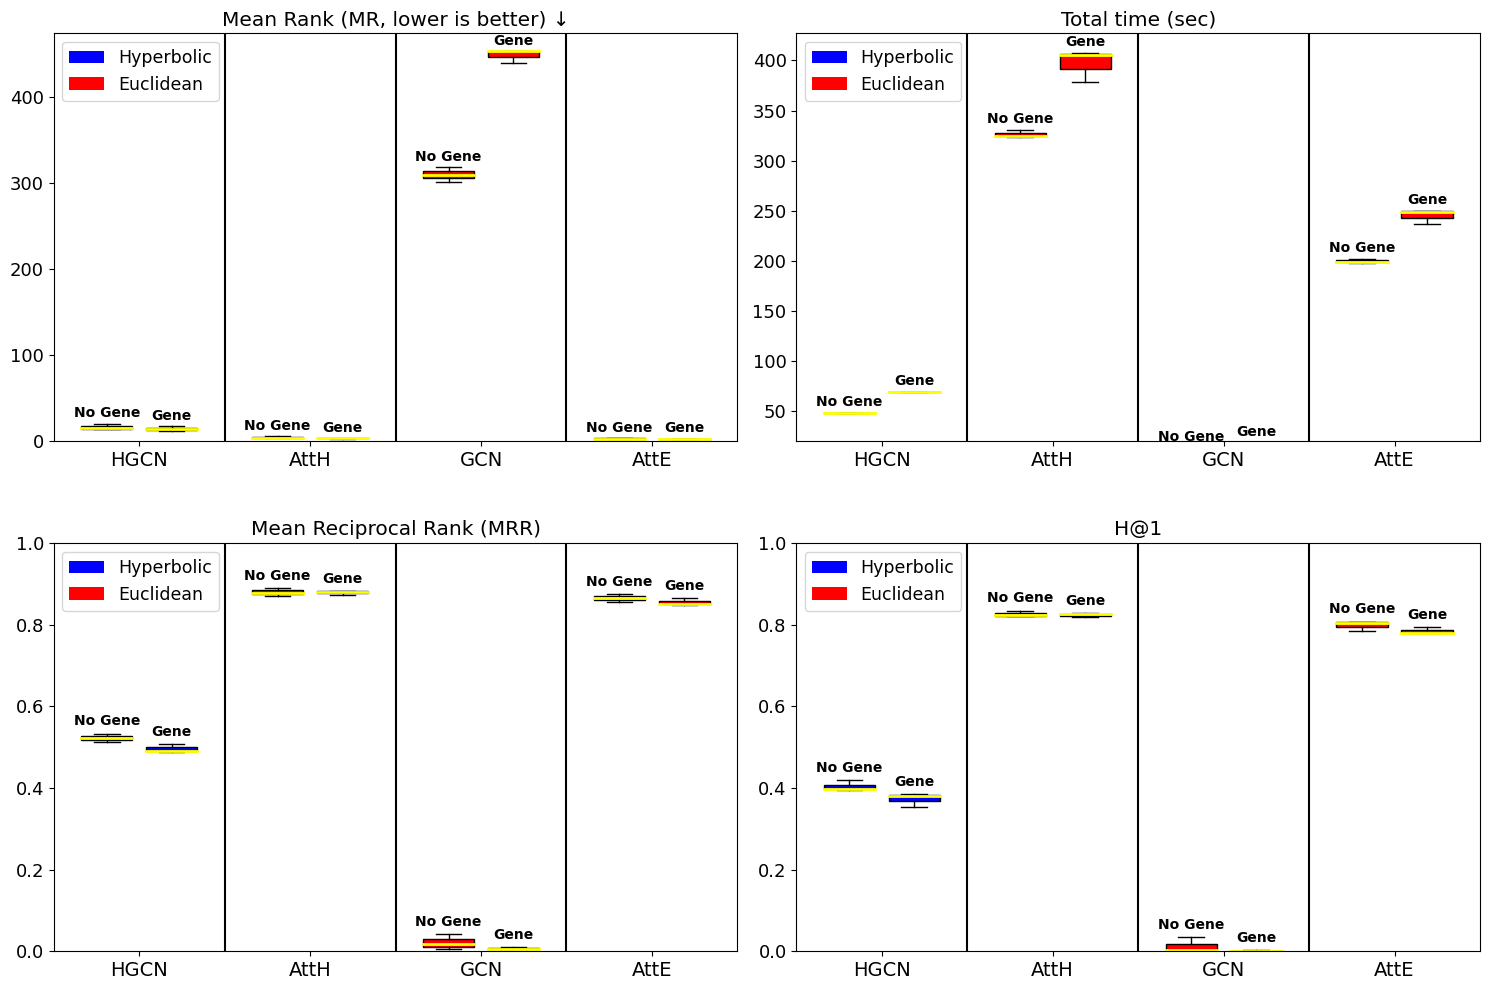

In [42]:
wd = 0.3
pps = [0, 1, 2, 3]
pos1 = np.array(pps)-wd/2-0.04
pos2 = np.array(pps)+wd/2+0.04
names = ["HGCN", "AttH", "GCN", "AttE"]

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

boxmr, boxmrr, boxh1, boxtime = [], [], [], []

for i in range(len(pps)):
    boxmr.append(axs[0, 0].boxplot(all_mr[i], positions=[pos1[i]], widths=wd, patch_artist=True))
    
    ymax = np.max(all_mr[i])+7
    axs[0, 0].text(pos1[i], ymax, "No Gene", fontsize=10, ha='center', fontweight='bold')
    
    boxmr.append(axs[0, 0].boxplot(all_mr2[i], positions=[pos2[i]], widths=wd, patch_artist=True))
    
    ymax = np.max(all_mr2[i])+7
    axs[0, 0].text(pos2[i], ymax, "Gene", fontsize=10, ha='center', fontweight='bold')
    
    boxtime.append(axs[0, 1].boxplot(all_time[i], positions=[pos1[i]], widths=wd, patch_artist=True))
    
    ymax = np.max(all_time[i])+7
    axs[0, 1].text(pos1[i], ymax, "No Gene", fontsize=10, ha='center', fontweight='bold')
    
    boxtime.append(axs[0, 1].boxplot(all_time2[i], positions=[pos2[i]], widths=wd, patch_artist=True))
    
    ymax = np.max(all_time2[i])+7
    axs[0, 1].text(pos2[i], ymax, "Gene", fontsize=10, ha='center', fontweight='bold')
    
    boxmrr.append(axs[1, 0].boxplot(all_mrr[i], positions=[pos1[i]], widths=wd, patch_artist=True))
    
    ymax = np.max(all_mrr[i])+0.02
    axs[1, 0].text(pos1[i], ymax, "No Gene", fontsize=10, ha='center', fontweight='bold')
    
    boxmrr.append(axs[1, 0].boxplot(all_mrr2[i], positions=[pos2[i]], widths=wd, patch_artist=True))
    
    ymax = np.max(all_mrr2[i])+0.02
    axs[1, 0].text(pos2[i], ymax, "Gene", fontsize=10, ha='center', fontweight='bold')
    
    boxh1.append(axs[1, 1].boxplot(all_h1[i], positions=[pos1[i]], widths=wd, patch_artist=True))
    
    ymax = np.max(all_h1[i])+0.02
    axs[1, 1].text(pos1[i], ymax, "No Gene", fontsize=10, ha='center', fontweight='bold')
    
    boxh1.append(axs[1, 1].boxplot(all_h12[i], positions=[pos2[i]], widths=wd, patch_artist=True))
    
    ymax = np.max(all_h12[i])+0.02
    axs[1, 1].text(pos2[i], ymax, "Gene", fontsize=10, ha='center', fontweight='bold')
    
    if i!=0:
        axs[0, 0].axvline(pps[i]-0.5, color="black")
        axs[0, 1].axvline(pps[i]-0.5, color="black")
        axs[1, 0].axvline(pps[i]-0.5, color="black")
        axs[1, 1].axvline(pps[i]-0.5, color="black")


# ticks e legenda
for ax in [axs[0, 0], axs[0, 1], axs[1, 0], axs[1, 1]]:
    ax.bar(0, 0, color="blue", label="Hyperbolic")
    ax.bar(0, 0, color="red", label="Euclidean")

    ax.set_xticks(pps)
    ax.set_xticklabels(names, fontsize=14)
    ax.tick_params(axis='y', labelsize=13)
    ax.legend(loc="upper left", fontsize=12.5)


def color_boxes(boxes):
    for i in range(len(boxes)):
        if i//2 == 0:
            boxes[i]['boxes'][0].set_facecolor('blue')
        else:
            boxes[i]['boxes'][0].set_facecolor('red')
        boxes[i]['medians'][0].set(color='yellow', linewidth=2)


for b in [boxmr, boxtime, boxmrr, boxh1]:
    color_boxes(b)


axs[0, 0].set_title("Mean Rank (MR, lower is better) ↓", fontsize=14.5)
axs[0, 1].set_title("Total time (sec)", fontsize=14.5)
axs[1, 0].set_title("Mean Reciprocal Rank (MRR)", fontsize=14.5)
axs[1, 1].set_title("H@1", fontsize=14.5)

axs[0, 0].set_ylim(0, np.max([all_mr, all_mr2])+20)
axs[0, 1].set_ylim(20, np.max([all_time, all_time2])+20)
axs[1, 0].set_ylim(0, 1)
axs[1, 1].set_ylim(0, 1)

plt.tight_layout()
for ax in axs.flat:
    ax.set_xlim(-0.5, len(pps)-0.5)
    ax.margins(x=0.01)

fig.subplots_adjust(hspace=0.25)
plt.show()

## Gap reduction su grafo ridotto

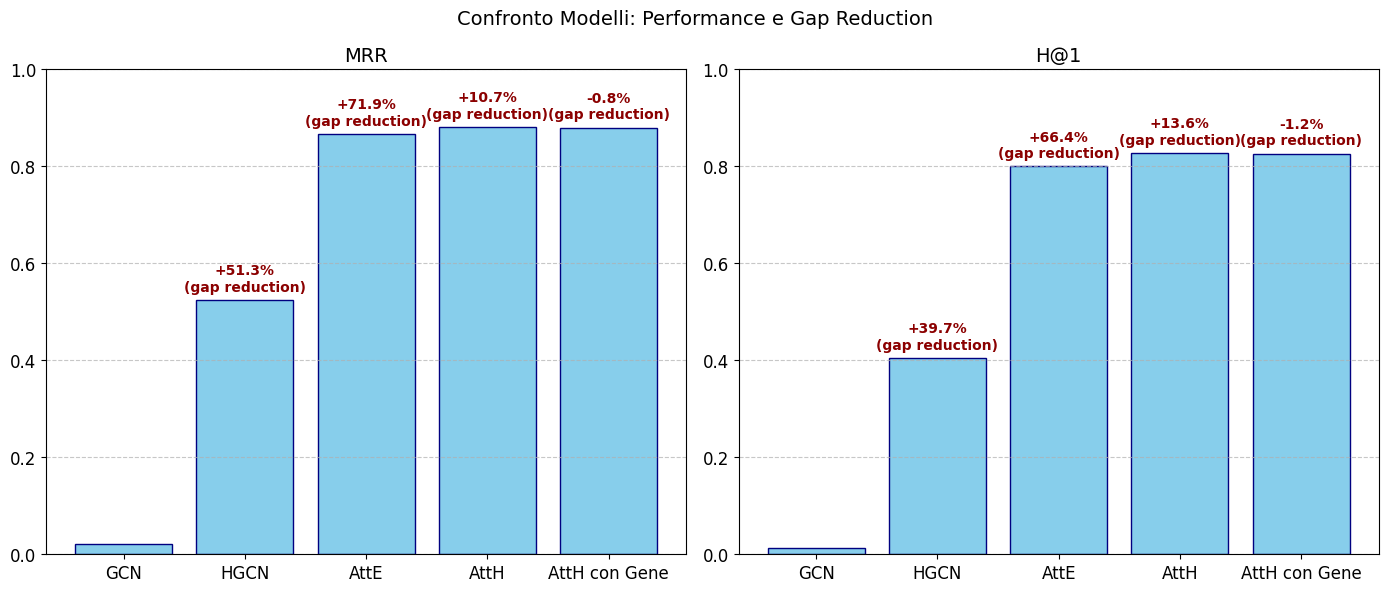

In [23]:
modelli = ["GCN", "HGCN", "AttE", "AttH", "AttH con Gene"]
mrr_values = np.mean(all_mrr, axis=1)
mrr_values.sort()
mrr_values = np.append(mrr_values, np.mean(all_mrr2[1]))

h1_values = np.mean(all_h1, axis=1)
h1_values.sort()
h1_values = np.append(h1_values, np.mean(all_h12[1]))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

barsMRR = ax[0].bar(modelli, mrr_values, color='skyblue', edgecolor='navy')
barsH1 = ax[1].bar(modelli, h1_values, color='skyblue', edgecolor='navy')

for i in range(1, len(modelli)):
    gapMRR = (mrr_values[i] - mrr_values[i-1]) / (1 - mrr_values[i-1])
    gapH1 = (h1_values[i] - h1_values[i-1]) / (1 - h1_values[i-1])
    
    if gapMRR>=0:
        ax[0].text(i, mrr_values[i] + 0.02, f"+{gapMRR:.1%}\n(gap reduction)", 
             ha='center', fontsize=10, fontweight='bold', color='darkred')
    else:
        ax[0].text(i, mrr_values[i] + 0.02, f"{gapMRR:.1%}\n(gap reduction)", 
             ha='center', fontsize=10, fontweight='bold', color='darkred')
        
    if gapH1>=0:    
        ax[1].text(i, h1_values[i] + 0.02, f"+{gapH1:.1%}\n(gap reduction)", 
             ha='center', fontsize=10, fontweight='bold', color='darkred')
    else:
        ax[1].text(i, h1_values[i] + 0.02, f"{gapH1:.1%}\n(gap reduction)", 
             ha='center', fontsize=10, fontweight='bold', color='darkred')

ax[0].set_ylim(0, 1)
ax[1].set_ylim(0, 1)

ax[0].set_title('MRR', fontsize=14)
ax[1].set_title('H@1', fontsize=14)

ax[0].grid(axis='y', linestyle='--', alpha=0.7)
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

ax[0].tick_params(axis='x', labelsize=12)
ax[1].tick_params(axis='x', labelsize=12)

ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='y', labelsize=12)

fig.suptitle('Confronto Modelli: Performance e Gap Reduction', fontsize=14)

plt.tight_layout()
plt.show()

## Gap reduction su grafo ridotto con Gene

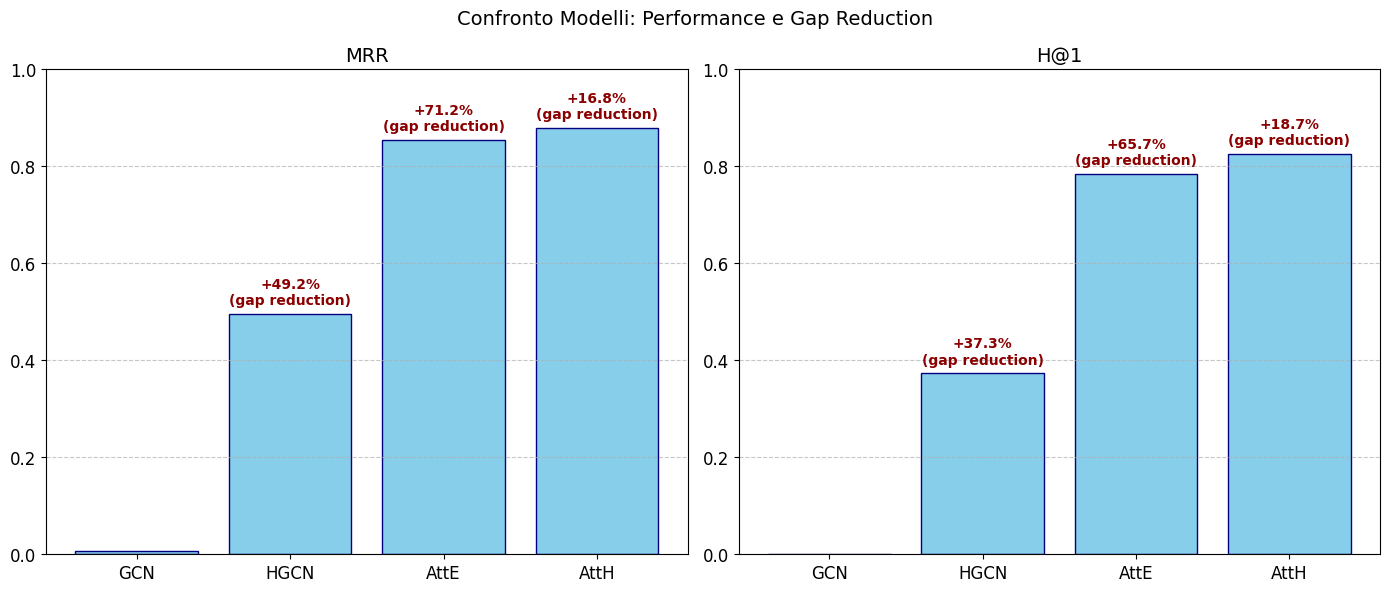

In [8]:
modelli = ["GCN", "HGCN", "AttE", "AttH"]
mrr_values = np.mean(all_mrr2, axis=1)
mrr_values.sort()
h1_values = np.mean(all_h12, axis=1)
h1_values.sort()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

barsMRR = ax[0].bar(modelli, mrr_values, color='skyblue', edgecolor='navy')
barsH1 = ax[1].bar(modelli, h1_values, color='skyblue', edgecolor='navy')

for i in range(1, len(modelli)):
    gapMRR = (mrr_values[i] - mrr_values[i-1]) / (1 - mrr_values[i-1])
    gapH1 = (h1_values[i] - h1_values[i-1]) / (1 - h1_values[i-1])
    
    
    ax[0].text(i, mrr_values[i] + 0.02, f"+{gapMRR:.1%}\n(gap reduction)", 
             ha='center', fontsize=10, fontweight='bold', color='darkred')
    ax[1].text(i, h1_values[i] + 0.02, f"+{gapH1:.1%}\n(gap reduction)", 
             ha='center', fontsize=10, fontweight='bold', color='darkred')

ax[0].set_ylim(0, 1)
ax[1].set_ylim(0, 1)

ax[0].set_title('MRR', fontsize=14)
ax[1].set_title('H@1', fontsize=14)

ax[0].grid(axis='y', linestyle='--', alpha=0.7)
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

ax[0].tick_params(axis='x', labelsize=12)
ax[1].tick_params(axis='x', labelsize=12)

ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='y', labelsize=12)

fig.suptitle('Confronto Modelli: Performance e Gap Reduction', fontsize=14)

plt.tight_layout()
plt.show()